# Insights on Power Flow Equations - to get a feel

In [2]:
import pandapower as pp
import sys 
import os 
import numpy as np 

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

np.set_printoptions(precision=4)

from utils.ppnet_utils import add_branch_parameters, calculate_bus_admittance_matrix

# create empty net
net = pp.create_empty_network()

# create buses
b1 = pp.create_bus(net, vn_kv=20., name="Bus 1")
b2 = pp.create_bus(net, vn_kv=20., name="Bus 2")
b3 = pp.create_bus(net, vn_kv=20., name="Bus 3")
b4 = pp.create_bus(net, vn_kv=0.4, name="Bus 4")

# create bus elements
pp.create_ext_grid(net, bus=b1, vm_pu=1.02, name="Grid Connection")
pp.create_load(net, bus=b2, p_mw=0.1, q_mvar=0.05, name="Load 1")
pp.create_load(net, bus=b3, p_mw=0.9, q_mvar=0., name="Load 2")
pp.create_sgen(net, bus=b4, p_mw=0.22, name="Gen 1")

# create branch elements
pp.create_transformer(net, hv_bus=b3, lv_bus=b4, std_type="0.4 MVA 20/0.4 kV", name="Trafo")
net.trafo.shift_degree = 0.0
pp.create_line(net, from_bus=b1, to_bus=b2, length_km=1.0, name="Line",std_type="NA2XS2Y 1x150 RM/25 12/20 kV")
pp.create_line(net, from_bus=b2, to_bus=b3, length_km=1.0, name="Line",std_type='NA2XS2Y 1x120 RM/25 12/20 kV')
pp.create_line(net, from_bus=b1, to_bus=b3, length_km=1.0, name="Line",std_type="NA2XS2Y 1x70 RM/25 12/20 kV")

np.int64(2)

No or insufficient geodata available --> Creating artificial coordinates. This may take some time


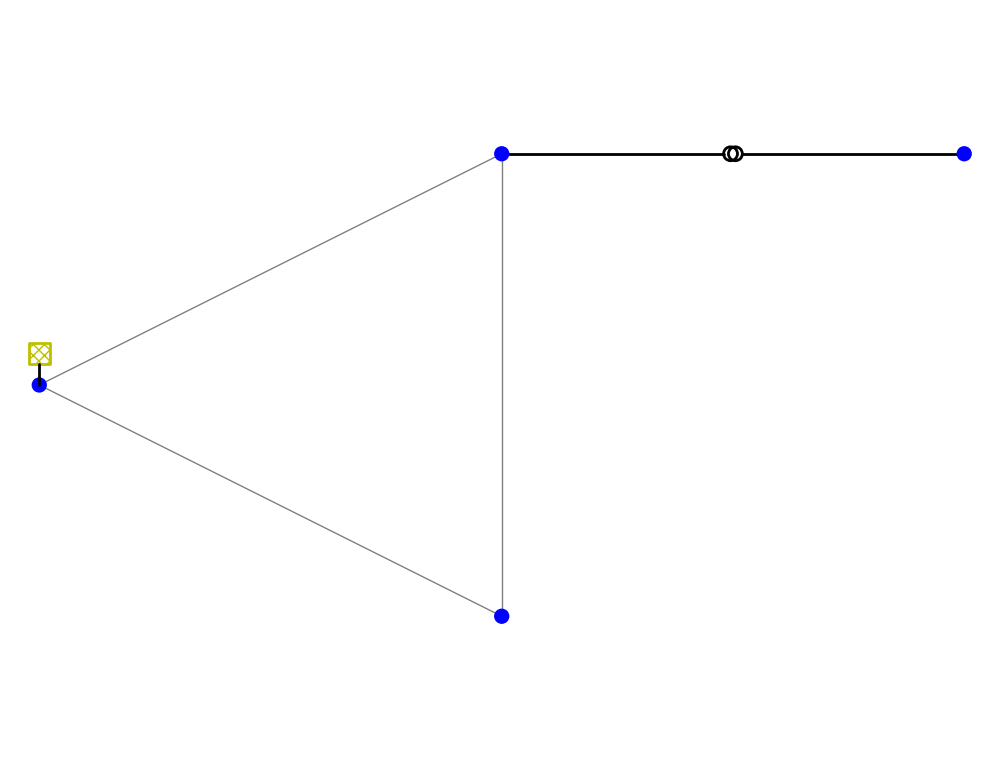

<Axes: >

In [3]:
pp.plotting.simple_plot(net)

### Add branch parameters 

In [4]:
net = add_branch_parameters(net)

### Calculate the bus-admittance matrix 

In [5]:
Y_bus = calculate_bus_admittance_matrix(net)

In [10]:
Y_bus

array([[ 2.3036e+03-1077.3067j, -1.4743e+03 +830.1725j,
        -8.2930e+02 +247.1066j,  0.0000e+00   +0.j    ],
       [-1.4743e+03 +830.1725j,  2.7689e+03-1439.1319j,
        -1.2946e+03 +608.9293j,  0.0000e+00   +0.j    ],
       [-8.2930e+02 +247.1066j, -1.2946e+03 +608.9293j,
         2.1255e+03 -862.5381j, -1.5833e+00   +6.4759j],
       [ 0.0000e+00   +0.j    ,  0.0000e+00   +0.j    ,
        -1.5833e+00   +6.4759j,  1.5850e+00   -6.4759j]])

In [7]:
pp.runpp(net)
Y_bus_internal = np.array(net._ppc['internal']['Ybus'].todense())
Y_bus_internal - Y_bus

array([[ 0.    +5.5292e-02j,  0.    +0.0000e+00j,  0.    +0.0000e+00j,
         0.    +0.0000e+00j],
       [ 0.    +0.0000e+00j,  0.    +6.0319e-02j,  0.    +0.0000e+00j,
         0.    +0.0000e+00j],
       [ 0.    +0.0000e+00j,  0.    +0.0000e+00j, -0.0014+5.2779e-02j,
         0.0003-1.6603e-08j],
       [ 0.    +0.0000e+00j,  0.    +0.0000e+00j,  0.0003-1.6603e-08j,
        -0.0014-1.6603e-08j]])

# Solve Power Flow Equations 

### Power Injection Equations: 



Using, 
$$
\begin{aligned}
P_i & = |V_i| \sum_{k=1}^n |V_k| |Y_{ik}| \cos(\theta_{ik} + \delta_k - \delta_i) \\
Q_i & = |V_i| \sum_{k=1}^n |V_k| |Y_{ik}| \sin(\theta_{ik} + \delta_k - \delta_i) \\
& \text{where} \\ 
& \theta_{ik} = \arg(Y_{ik})
\end{aligned}
$$

we get: 



$$
\begin{aligned}
(1) & \quad  P_1: 1725.78 |V_2| \cos(\delta_2 + 2.63) + 882.65 |V_3| \cos(\delta_3 + 2.85) + 2397.07 = P_1 \\ 
(2) & \quad Q_1: - 1725.78 |V_2| \sin(\delta_2 + 2.63) - 882.65 |V_3| \sin(\delta_3 + 2.85) + 119.76 = Q_1 \\ 
(3) & \quad P_2: 2769.35 |V_2|^2 + 1725.78 |V_2| \cos(2.63 - \delta_2) + 1430.67 |V_2| |V_3| \cos(2.702 + \delta_3 - \delta_2) = - 0.1 \\ 
(4) & \quad Q_2: 1438.25 |V_2|^2 - 1725.78 |V_2| \sin(2.63 - \delta_2) - 1430.67 |V_2| |V_3| \sin(2.70 + \delta_3 - \delta_2) = -0.05 \\
(5) & \quad P_3: 2198.07 |V_3|^2 + 882.65 |V_3| \cos(2.85 - \delta_3) + 1430.67 |V_2| |V_3| \cos(2.70 + \delta_2 - \delta_3) + 6.67 |V_3||V_4| \cos(1.81 + \delta_4 - \delta_3) = -0.9 \\
(6) & \quad Q_3: 655.93 |V_3|^2 - 882.65 |V_3| \sin(2.85 - \delta_3) - 1430.67 |V_2| |V_3| \sin(2.70 + \delta_2 - \delta_3) - 6.67 |V_3||V_4| \sin(1.81 + \delta_4 - \delta_3) = 0.0 \\
(7) & \quad P_4: 1.60 |V_4|^2 + 6.67 |V_3| |V_4| \cos(1.81 + \delta_3 - \delta_4) = 0.22 \\
(8) & \quad Q_4: 6.48 |V_4|^2 - 6.67 |V_3| |V_4| \sin(1.81 + \delta_3 - \delta_4) = 0.0 \\
\end{aligned}
$$



### Power Flow Equations: 
For sending bus and recieving bus denoted by $S$ and $R$ respectively, and bus admittance matrix between these buses as 

$$
\begin{aligned}

\begin{bmatrix}
I_S \\ 
I_R \end{bmatrix} = \begin{bmatrix} Y_{SS} & Y_{SR} \\
                                    Y_{RS} & Y_{RR} \end{bmatrix} 
\begin{bmatrix} V_S \\ 
                V_R 
\end{bmatrix}

\end{aligned}
$$

Using, 

$$
\begin{aligned}
P_{S \rightarrow R} &= \frac{|V_S||V_R|\cos(\beta - \delta_R - \delta_S)}{|\frac{-Y_{RR}}{Y_{RS}}|} - \frac{|\frac{1}{Y_{RS}}| |V_R|^2  \cos(\beta - \alpha)}{|-\frac{Y_{RR}}{Y_{RS}}|} \\ 
Q_{S \rightarrow R} &= \frac{|V_S||V_R|\sin(\beta - \delta_R - \delta_S)}{|\frac{-Y_{RR}}{Y_{RS}}|} - \frac{|\frac{1}{Y_{RS}}| |V_R|^2  \sin(\beta - \alpha)}{|-\frac{Y_{RR}}{Y_{RS}}|} \\ 
\end{aligned}
$$

$$
\begin{aligned}
P_{R \rightarrow S} &= \frac{ |Y_{SR} - \frac{Y_{SS}Y_{RR}}{Y_{RS}}| |V_S|^2 \cos(\beta - \alpha) }{ |\frac{-Y_{RR}}{Y_{RS}}| } - \frac{|V_S||V_R| \cos(\beta + \delta_R - \delta_S)}{|\frac{-Y_{RR}}{Y_{RS}}|} \\ 
Q_{R \rightarrow S} &= \frac{ |Y_{SR} - \frac{Y_{SS}Y_{RR}}{Y_{RS}}| |V_S|^2 \sin(\beta - \alpha) }{ |\frac{-Y_{RR}}{Y_{RS}}| } - \frac{|V_S||V_R| \sin(\beta + \delta_R - \delta_S)}{|\frac{-Y_{RR}}{Y_{RS}}|} \\ 
\text{where,} \\ 
\beta & = \arg \left(\frac{-Y_{RR}}{Y_{RS}} \right) \\
\alpha & = \arg \left( \frac{1}{Y_{RS}} \right) \\ 
\end{aligned}
$$


In [7]:
pp.runpp(net)

In [13]:
net.res_bus

,vm_pu,va_degree,p_mw,q_mvar
0,1.020000,0.000000,-0.783331,0.030797
1,1.019787,-0.005275,0.100000,0.050000
2,1.019596,-0.009476,0.900000,0.000000
3,1.026728,1.739630,-0.220000,0.000000


In [9]:
net.res_line

,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent
0,0.399146,0.022462,-0.399067,-0.055096,0.000080,-0.032633,0.011314,0.011404,0.011404,1.020000,0.000000,1.019787,-0.005275,3.574823
1,0.299067,0.005096,-0.299012,-0.035122,0.000055,-0.030026,0.008467,0.008524,0.008524,1.019787,-0.005275,1.019596,-0.009476,3.012028
2,0.384185,-0.053259,-0.384026,0.028475,0.000159,-0.024784,0.010977,0.010903,0.010977,1.020000,0.000000,1.019596,-0.009476,4.989537


In [10]:
net.res_trafo 

,p_hv_mw,q_hv_mvar,p_lv_mw,q_lv_mvar,pl_mw,ql_mvar,i_hv_ka,i_lv_ka,vm_hv_pu,va_hv_degree,vm_lv_pu,va_lv_degree,loading_percent
0,-0.216962,0.006647,0.22,2.775558e-16,0.003038,0.006647,0.006146,0.309276,1.019596,-0.009476,1.026728,1.73963,53.56821


In [11]:
net.line

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,...,r_pu,x_pu,b_pu,g_pu,tap_nom,shift_rad,a_1,a_2,a_3,a_4
0,Line,NA2XS2Y 1x150 RM/25 12/20 kV,0,1,1.0,0.206,0.116,250.0,0.0,0.319,...,0.000515,0.000290,0.031416,0.0,0,0,1474.271810- 830.188183j,-1474.271810+ 830.172475j,-1474.271810+ 830.172475j,1474.271810- 830.188183j
1,Line,NA2XS2Y 1x120 RM/25 12/20 kV,1,2,1.0,0.253,0.119,230.0,0.0,0.283,...,0.000633,0.000297,0.028903,0.0,0,0,1294.614302- 608.943708j,-1294.614302+ 608.929257j,-1294.614302+ 608.929257j,1294.614302- 608.943708j
2,Line,NA2XS2Y 1x70 RM/25 12/20 kV,0,2,1.0,0.443,0.132,190.0,0.0,0.220,...,0.001107,0.000330,0.023876,0.0,0,0,829.304592- 247.118498j,-829.304592+ 247.106560j,-829.304592+ 247.106560j,829.304592- 247.118498j


In [12]:
net.trafo

,name,std_type,hv_bus,lv_bus,sn_mva,vn_hv_kv,vn_lv_kv,vk_percent,vkr_percent,pfe_kw,...,r_pu,x_pu,b_pu,g_pu,shift_rad,tap_nom,a_1,a_2,a_3,a_4
0,Trafo,0.4 MVA 20/0.4 kV,2,3,0.4,20.0,0.4,6.0,1.425,1.35,...,0.035625,0.145708,0.0,0.003375,0.0,1.0,1.585021-6.475917j,-1.583333+6.475917j,-1.583333+6.475917j,1.585021-6.475917j


### Transformer parameters calculation 

The way internal pandapower calculates the Bus admittance for transformer was not clear, so I used the theory (from books) to obtain the transformer parameters, using the short circuit and open circuit test parameters. 

NOTE: 
1. Short-circuit test (SCT) is carried out at the HV side. 
2. Open-circuit test (OCT) is carried out at the LV side. 
3. Parameters for calculating the series impedance using SCT: `vk_percent`, `vkr_percent` with base voltages at HV side. 
4. Parameters for calculating the shunt impedance using OCT: `i0_percent`, `pfe_kw` representing the no load current and iron losses respectively. 

Finding series parameters: $R_{s}$ and $X_{s}$ using SCT: 
  
1. Base impedance: $Z_{BASE} = \frac{V_{HV}^2}{S_{n,trafo}} = \frac{(20kV)^2}{0.4 MVA} = 400 \Omega$.
2. $V_{k} =$ `vk_percent`/100 * $V_{HV} = \frac{6}{100} * 20 * 10^{3} = 1.2kV$ and similarly, $V_{kr} = 0.285kV$.
3. Using the transformer ratio, $I_{HV} = 20A$. 
4. Series impedance: $Z_{s} = \frac{V_{k}}{I_{HV}Z_{BASE}} = \frac{1.2kV}{20*400} = 0.150pu$.
5. Series resistance: $R_{s} = \frac{V_{kr}}{I_{HV}Z_{BASE}} = \frac{0.285kV}{20*400} = 0.03525pu$. 
6. From above results, $X_{s} = \sqrt{Z_s^2 - R_{s}^2} = 0.1457pu$.

Finding shunt parameters: $R_{sh}$ and $X_{sh}$ using OCT: 

1. Base current $I_{LV} = 1000A$, so, no load current $I_0 =$ `i0_percent`$/100 * I_{HV} = \frac{0.3375}{100} * 1000 = 3.375A$. 
2. Base impedance $Z_{BASE,LV} = \frac{V_{LV}^2}{S_{n,trafo}} = \frac{(0.4kV)^2}{0.4MVA} = 0.4\Omega$. 
3. Rated voltage $V_{LV} = 0.4kV$, since OCT. 
4. Power factor angle: $\cos{\phi_{0}} =$ `pfe_kw` $/(V_{LV}I_0) = 1.0$. 
5. So, $X_{0} = \frac{I_{0} \sin{\phi_0}V_1}{I_0^2} = 0.0$.
6. So, $R_{0} = \frac{I_{0} \cos{\phi_0}V_1}{I_0^2} = 118.518$.
7. $G_0 = \frac{1}{R_{0}} * Z_{BASE,LV} = \frac{0.4}{118.518} = 0.003375pu$. 
8. No $B_0$ since power factor angle $= 1.0$. 
